# Part 3: Water Quality Rating 

One reason to monitor water quality is to check whether the water is meeting standards for a healthy ecosystem or for recreational and cultural use. For example, certain species of freshwater fish prefer cooler temperatures, and too much or too little dissolved oxygen can harm freshwater organisms. There are recommended thresholds we will check for in this section. 

We will use the function `ifelse()` to see if a value meets a condition, in this case for temperature, dissolved oxygen, and conductivity. Then we will calculate how often the conditions are considered healthy at each site, and plot the results using `ggplot2`. 

*Note: if you are starting here and have not recently done Part 1: Intro to K'avi Tribe Water Quality, you may want to go back and review*

In [2]:
# load necessary libraries
library(tidyverse)
# make plots larger 
options(repr.plot.width = 10, repr.plot.height = 8)

# important cleaned water quality dataset
water <- read.csv("https://raw.githubusercontent.com/IndigenousEnvDataSci/IndigenousEnvDataSci.github.io/refs/heads/main/KAVI/data/K-avi_tribe_water_quality_dataset_clean.csv")
tek_sum <- read.csv("https://raw.githubusercontent.com/IndigenousEnvDataSci/IndigenousEnvDataSci.github.io/refs/heads/main/KAVI/data/tek_summary.csv")

## Rate water quality data 

To simplify the water quality checks, we are creating new columns in the `water` data frame that will be either 1 (for pass) or 0 (for fail). 
We will use the `mutate()` function to create new columns for each water quality metric, labeled with `_check`. At each measurement date, these new columns will show whether it passes or fails based on the K'avi water quality standards:

- for temperature, we want values at or below 15°C
- for dissolved oxygen, at or above 12mg/L
- for specific conductivity, we want values less than 400 ℧/m

Here we use the `if_else()` function, which takes a conditional and assigns a value based on whether the condition is True or False. For example: 

`if_else(conditional, TRUE, FALSE)` 



In [4]:
water <- water %>%
  mutate(temp_check = if_else(water_temp_C <= 15, 1, 0), 
         DO_check = if_else(DO >= 12, 1, 0),
         SC_check = if_else(specific_conductivity <= 400, 1, 0))

head(water)

,X,sample_location,longitude,latitude,date,DO,water_temp_C,water_temp_F,specific_conductivity,discharge,year,temp_check,DO_check,SC_check
,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,1,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-01-15,12.3,0.3,32.54,80,35,1990,1,1,1
2,2,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-02-01,12.3,0.4,NA,82,27,1990,1,1,1
3,3,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-03-15,12.3,0.4,NA,93,20,1990,1,1,1
4,4,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-04-12,11.9,0.5,NA,85,26,1990,1,0,1
5,5,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-05-11,11.8,4.0,NA,110,100,1990,1,0,1
6,6,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-06-15,10.9,5.9,NA,180,261,1990,1,0,1


### Summarize water quality checks 

Now that we know when each standard passes / fails, we can count them to figure out how often each sampling location passes and fails based on each measurement.

Next we group by the sample location and summarize the checks into number of passes by adding them up (pass = 1, so we can use `sum()` to count the number of passes). 

In the following code, we create a new data frame called `rank_sum` by starting with the `water`data frame, then using `add_count()` to create a new column with the number of observations per sample location. The data is grouped by count and sample location to get number of passes and percent for each metric.


In [45]:
rank_sum <- water %>%
  # get the number of samples collected at each site
  add_count(sample_location) %>%   
  # group the data by the sampling location and count 
  group_by(sample_location, n) %>%
  # summarize the check columns 
  summarise(# find the number of times the temperature measurement passed the K'avi standards
            temp_pass = sum(temp_check),
            # find the number of times the DO measurement passed the K'avi standards
            DO_pass = sum(DO_check),
            # find the number of times the specific conductivity measurement passed the K'avi standards 
            SC_pass = sum(SC_check)) %>% 
  # add new columns 
  mutate(# calculate the % pass rate for temp measurements / site
            temp_percent = temp_pass / n * 100,
      # calculate the % pass rate for DO measurements / site
            DO_percent = DO_pass / n * 100,
      # calculate the % pass rate for conductivity measurements / site
            SC_percent = SC_pass / n * 100,
      # calculate the average failure rate for each site across all water quality measurements
            average_pass = mean(c(temp_percent, DO_percent, SC_percent)))

# print the new dataframe 
rank_sum

`summarise()` has grouped output by 'sample_location'. You can override using the `.groups` argument.


sample_location,n,temp_pass,DO_pass,SC_pass,temp_percent,DO_percent,SC_percent,average_pass
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Monitoring Site 1,132,123,18,132,93.18182,13.63636,100,68.93939
Monitoring Site 2,132,108,15,132,81.81818,11.36364,100,64.39394
Monitoring Site 3,132,100,0,132,75.75758,0.00000,100,58.58586
Monitoring Site 4,132,118,0,132,89.39394,0.00000,100,63.13131
Monitoring Site 5,33,33,0,33,100.00000,0.00000,100,66.66667


Joining with `by = join_by(sample_location, n)`


### Join with survey data 

With the new data frame `rank_sum`, each row is a sample location. We can combine this with the TEK survey data that was summarized by sample location using `inner_join()`. 

In [49]:
## create a new data frame that merges water quality ranking data with TEK data
rank_tek_sum <- inner_join(rank_sum, tek_sum, by='sample_location')

head(rank_tek_sum)

sample_location,n.x,temp_pass,DO_pass,SC_pass,temp_percent,DO_percent,SC_percent,average_pass,X,site,mean_tek,sd,n.y,se_tek
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>
Monitoring Site 1,132,123,18,132,93.18182,13.63636,100,68.93939,1,Ceremony.Site,2.00,0.0000000,4,0.0000000
Monitoring Site 2,132,108,15,132,81.81818,11.36364,100,64.39394,5,Medicinal.Food.Site,3.75,0.9574271,4,0.4787136
Monitoring Site 3,132,100,0,132,75.75758,0.00000,100,58.58586,3,Hunting.Grounds,2.25,1.5000000,4,0.7500000
Monitoring Site 4,132,118,0,132,89.39394,0.00000,100,63.13131,2,Fishing.Site,4.50,1.0000000,4,0.5000000
Monitoring Site 5,33,33,0,33,100.00000,0.00000,100,66.66667,4,Language.Camp,2.50,1.7320508,4,0.8660254


## Visualize the data 

We can recreate the plots from part 2, however we don't have standard error to represent the water quality standards passing rate which we will put on the x-axis. So we only need errorbars for the y-axis. 

💻**Your turn!** Try adding a ggplot that shows the passing rates for each of the water quality metrics (temperature, DO, specific conductivity) at each site, along with TEK ranking information. Consider different ways to visualize it, and how you would communicate this. Try out `geom_col()`, and change around the x-axis and fill aesthetics. 

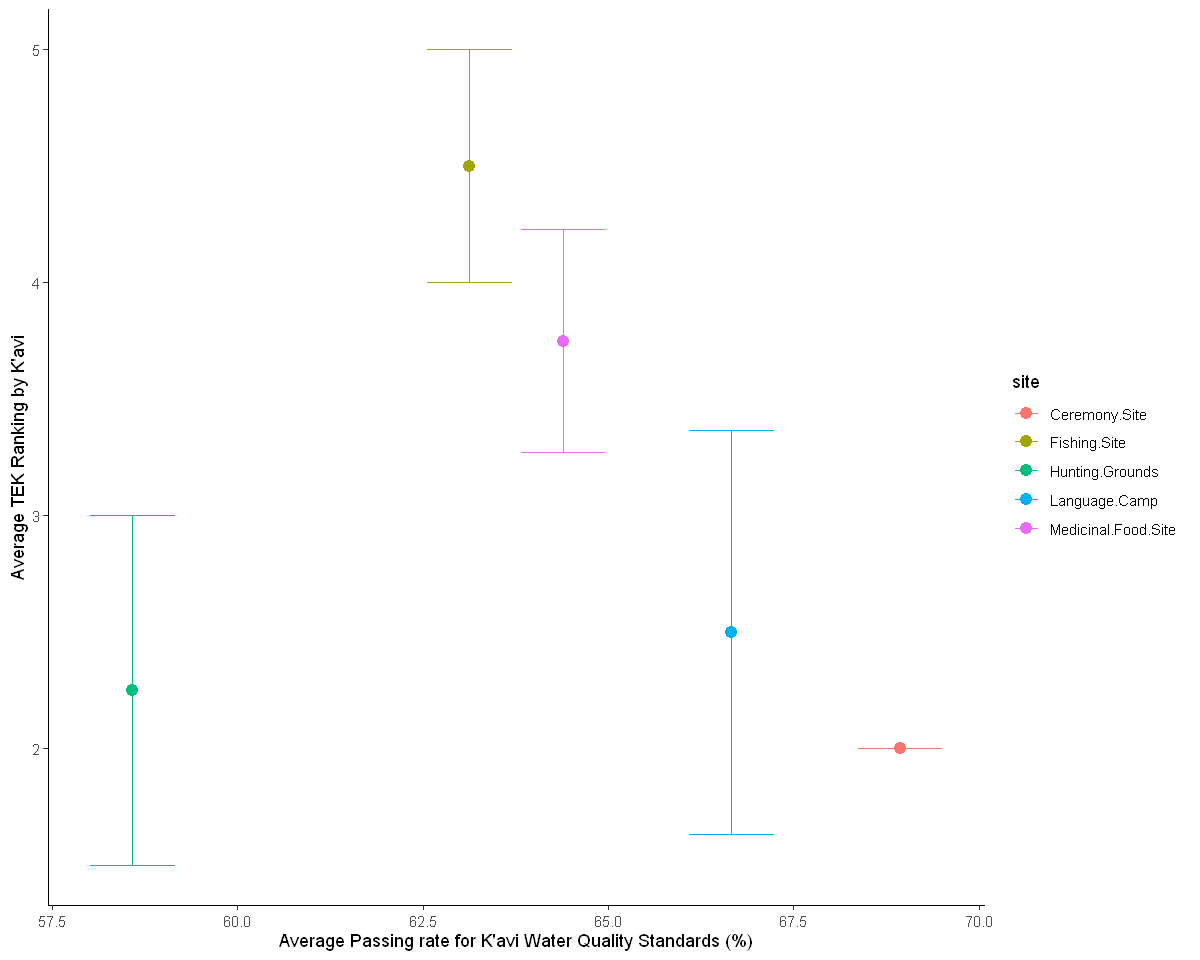

In [56]:
rank_tek_sum %>%
  ggplot(aes(x = average_pass, y = mean_tek, color=site)) +
  # plot these data as points, make the point size larger so it's more visible,
  # and color by monitoring site
  geom_errorbar(aes(ymin = mean_tek - se_tek, ymax = mean_tek + se_tek)) + 
  # add a point 
  geom_point(size=3) +
  # add x-axis label
  xlab("Average Passing rate for K'avi Water Quality Standards (%)") +
  # add y-axis label
  ylab("Average TEK Ranking by K'avi") +
  # clean up plot by changing the theme
  theme_classic()

🧠✍️ **Questions** 

- What other plots could be made? 
- What variables would be useful to visualize? 

## Part 3 Recap 

Topics covered in this section:

- Introduced the `ifelse()` to create new column  in this part 
- Summarised by percent of samples that failed test and plotted
- Joined data frames by sample location for summarized data of TEK survey and water quality checks
- Plotted the percent of water quality pass and TEK rank for each sample location